In [1]:
!pip install -q sentence-transformers scikit-learn pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import re
import json

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, classification_report

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Semantic evaluation model loaded!")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Semantic evaluation model loaded!


In [4]:
data = [
    {
        "id": 1,
        "context": "The user is learning Python and SQL and wants to become a Data Analyst.",
        "prompt": "What project should I build next?",
        "response_a": "You could build an analytics assistant using Python and SQL. Adding a Power BI dashboard would also demonstrate business analytics skills.",
        "response_b": "Since you are an expert computer vision engineer, build a large CNN image classification system.",
        "human_winner": "A"
    },

    {
        "id": 2,
        "context": "The user has experience with Power BI and wants to improve business analytics.",
        "prompt": "What should I learn next?",
        "response_a": "You could improve your SQL and DAX skills and learn more advanced Power BI techniques.",
        "response_b": "You should focus on advanced Android development because you already have strong mobile development experience.",
        "human_winner": "A"
    },

    {
        "id": 3,
        "context": "The user wants to prepare for a Data Analyst interview.",
        "prompt": "How should I prepare?",
        "response_a": "Practice SQL, data interpretation, Excel or Power BI questions, and be ready to explain your projects clearly.",
        "response_b": "Focus mainly on Kubernetes administration and DevOps architecture.",
        "human_winner": "A"
    },

    {
        "id": 4,
        "context": "The user has completed a customer churn prediction project using Python and machine learning.",
        "prompt": "How can I improve my project?",
        "response_a": "Add feature importance, model evaluation, error analysis, and a dashboard explaining the main churn drivers.",
        "response_b": "Convert the project into a multiplayer mobile game because you specialize in Android development.",
        "human_winner": "A"
    },

    {
        "id": 5,
        "context": "The user is learning machine learning but has limited deep learning experience.",
        "prompt": "Should I start learning CNNs?",
        "response_a": "Yes, but first become comfortable with core machine learning concepts and basic neural networks before moving deeper into CNNs.",
        "response_b": "You are already an advanced computer vision researcher, so you should immediately build a large-scale CNN system.",
        "human_winner": "A"
    }
]

df = pd.DataFrame(data)

df

,id,context,prompt,response_a,response_b,human_winner
0,1,The user is learning Python and SQL and wants ...,What project should I build next?,You could build an analytics assistant using P...,Since you are an expert computer vision engine...,A
1,2,The user has experience with Power BI and want...,What should I learn next?,You could improve your SQL and DAX skills and ...,You should focus on advanced Android developme...,A
2,3,The user wants to prepare for a Data Analyst i...,How should I prepare?,"Practice SQL, data interpretation, Excel or Po...",Focus mainly on Kubernetes administration and ...,A
3,4,The user has completed a customer churn predic...,How can I improve my project?,"Add feature importance, model evaluation, erro...",Convert the project into a multiplayer mobile ...,A
4,5,The user is learning machine learning but has ...,Should I start learning CNNs?,"Yes, but first become comfortable with core ma...",You are already an advanced computer vision re...,A


In [5]:
def semantic_similarity(text1, text2):

    embeddings = model.encode(
        [text1, text2],
        normalize_embeddings=True
    )

    similarity = cosine_similarity(
        [embeddings[0]],
        [embeddings[1]]
    )[0][0]

    return round(float(similarity), 4)

In [6]:
test_score = semantic_similarity(
    df.loc[0, "context"],
    df.loc[0, "response_a"]
)

print("Semantic Similarity:", test_score)

Semantic Similarity: 0.5252


In [7]:
def grounding_score(context, response):

    similarity = semantic_similarity(
        context,
        response
    )

    score = round(
        similarity * 10,
        2
    )

    return score

In [8]:
for i in range(len(df)):

    score_a = grounding_score(
        df.loc[i, "context"],
        df.loc[i, "response_a"]
    )

    score_b = grounding_score(
        df.loc[i, "context"],
        df.loc[i, "response_b"]
    )

    print(
        f"Case {i+1}: "
        f"A={score_a}/10 | "
        f"B={score_b}/10"
    )

Case 1: A=5.25/10 | B=1.83/10
Case 2: A=5.93/10 | B=1.57/10
Case 3: A=5.55/10 | B=1.48/10
Case 4: A=5.45/10 | B=1.54/10
Case 5: A=4.35/10 | B=3.57/10


In [9]:
def personalization_score(context, response):

    context_embedding = model.encode(
        context,
        normalize_embeddings=True
    )

    response_embedding = model.encode(
        response,
        normalize_embeddings=True
    )

    similarity = cosine_similarity(
        [context_embedding],
        [response_embedding]
    )[0][0]

    return round(
        float(similarity * 10),
        2
    )

In [10]:
for i in range(len(df)):

    score = personalization_score(
        df.loc[i, "context"],
        df.loc[i, "response_a"]
    )

    print(
        f"Case {i+1}: {score}/10"
    )

Case 1: 5.25/10
Case 2: 5.93/10
Case 3: 5.55/10
Case 4: 5.45/10
Case 5: 4.35/10


In [11]:
def extract_sentences(text):

    sentences = re.split(
        r'(?<=[.!?])\s+',
        text.strip()
    )

    return [
        s.strip()
        for s in sentences
        if s.strip()
    ]


def unsupported_claim_detection(context, response):

    context_sentences = extract_sentences(context)
    response_sentences = extract_sentences(response)

    unsupported = []

    for sentence in response_sentences:

        max_similarity = 0

        for context_sentence in context_sentences:

            similarity = semantic_similarity(
                context_sentence,
                sentence
            )

            max_similarity = max(
                max_similarity,
                similarity
            )

        if max_similarity < 0.25:

            unsupported.append(sentence)

    return unsupported

In [12]:
for i in range(len(df)):

    unsupported = unsupported_claim_detection(
        df.loc[i, "context"],
        df.loc[i, "response_b"]
    )

    print(f"\nCase {i+1}")
    print("Unsupported claims:")
    print(unsupported)


Case 1
Unsupported claims:
['Since you are an expert computer vision engineer, build a large CNN image classification system.']

Case 2
Unsupported claims:
['You should focus on advanced Android development because you already have strong mobile development experience.']

Case 3
Unsupported claims:
['Focus mainly on Kubernetes administration and DevOps architecture.']

Case 4
Unsupported claims:
['Convert the project into a multiplayer mobile game because you specialize in Android development.']

Case 5
Unsupported claims:
[]


In [13]:
def instruction_following_score(prompt, response):

    similarity = semantic_similarity(
        prompt,
        response
    )

    return round(
        similarity * 10,
        2
    )

In [14]:
for i in range(len(df)):

    score = instruction_following_score(
        df.loc[i, "prompt"],
        df.loc[i, "response_a"]
    )

    print(
        f"Case {i+1}: {score}/10"
    )

Case 1: 2.15/10
Case 2: 2.67/10
Case 3: 2.88/10
Case 4: 1.53/10
Case 5: 7.19/10


In [15]:
def evaluate_response(
    context,
    prompt,
    response
):

    grounding = grounding_score(
        context,
        response
    )

    personalization = personalization_score(
        context,
        response
    )

    instruction = instruction_following_score(
        prompt,
        response
    )

    unsupported = unsupported_claim_detection(
        context,
        response
    )

    hallucination_penalty = min(
        len(unsupported) * 1.5,
        5
    )

    overall = (
        grounding * 0.30
        + personalization * 0.25
        + instruction * 0.25
        + 8 * 0.20
        - hallucination_penalty
    )

    overall = max(
        0,
        min(10, overall)
    )

    return {
        "grounding": round(grounding, 2),
        "personalization": round(personalization, 2),
        "instruction_following": round(instruction, 2),
        "unsupported_claims": unsupported,
        "hallucination_penalty": hallucination_penalty,
        "overall": round(overall, 2)
    }

In [16]:
def compare_responses(row):

    result_a = evaluate_response(
        row["context"],
        row["prompt"],
        row["response_a"]
    )

    result_b = evaluate_response(
        row["context"],
        row["prompt"],
        row["response_b"]
    )

    if result_a["overall"] > result_b["overall"]:
        winner = "A"

    elif result_b["overall"] > result_a["overall"]:
        winner = "B"

    else:
        winner = "Tie"

    return result_a, result_b, winner

In [17]:
results = []

for _, row in df.iterrows():

    result_a, result_b, winner = compare_responses(row)

    results.append({
        "id": row["id"],
        "A_score": result_a["overall"],
        "B_score": result_b["overall"],
        "predicted_winner": winner,
        "human_winner": row["human_winner"]
    })

results_df = pd.DataFrame(results)

results_df

,id,A_score,B_score,predicted_winner,human_winner
0,1,5.03,1.91,A,A
1,2,5.53,1.89,A,A
2,3,5.37,1.40,A,A
3,4,4.98,1.68,A,A
4,5,5.79,5.23,A,A


In [18]:
accuracy = accuracy_score(
    results_df["human_winner"],
    results_df["predicted_winner"]
)

print(
    f"Automated evaluator accuracy: "
    f"{accuracy * 100:.2f}%"
)

Automated evaluator accuracy: 100.00%


In [19]:
print("=" * 60)
print("AI RESPONSE QUALITY EVALUATION REPORT")
print("=" * 60)

for _, row in df.iterrows():

    result_a, result_b, winner = compare_responses(row)

    print(f"\nTEST CASE {row['id']}")
    print("-" * 60)

    print("Prompt:")
    print(row["prompt"])

    print("\nResponse A Score:", result_a["overall"])
    print("Response B Score:", result_b["overall"])

    print("\nPredicted Winner:", winner)
    print("Human Reference:", row["human_winner"])

    print("\nResponse A Unsupported Claims:")
    print(result_a["unsupported_claims"])

    print("\nResponse B Unsupported Claims:")
    print(result_b["unsupported_claims"])

AI RESPONSE QUALITY EVALUATION REPORT

TEST CASE 1
------------------------------------------------------------
Prompt:
What project should I build next?

Response A Score: 5.03
Response B Score: 1.91

Predicted Winner: A
Human Reference: A

Response A Unsupported Claims:
[]

Response B Unsupported Claims:
['Since you are an expert computer vision engineer, build a large CNN image classification system.']

TEST CASE 2
------------------------------------------------------------
Prompt:
What should I learn next?

Response A Score: 5.53
Response B Score: 1.89

Predicted Winner: A
Human Reference: A

Response A Unsupported Claims:
[]

Response B Unsupported Claims:
['You should focus on advanced Android development because you already have strong mobile development experience.']

TEST CASE 3
------------------------------------------------------------
Prompt:
How should I prepare?

Response A Score: 5.37
Response B Score: 1.4

Predicted Winner: A
Human Reference: A

Response A Unsupported

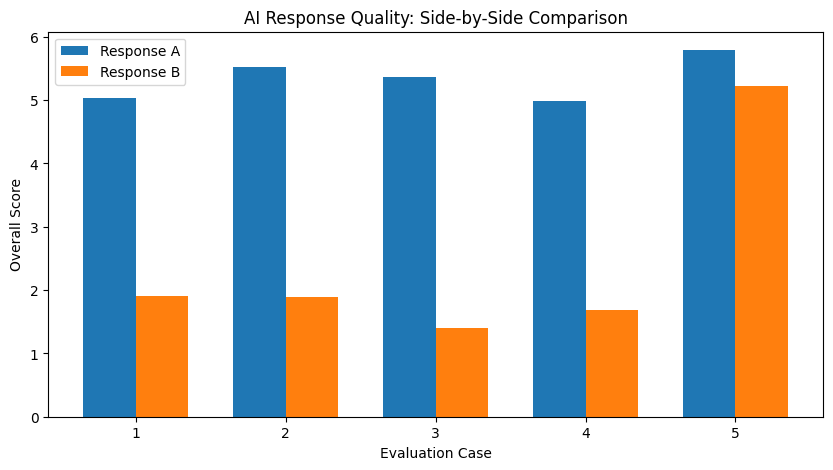

In [20]:
import matplotlib.pyplot as plt

metrics = [
    "A_score",
    "B_score"
]

plt.figure(figsize=(10, 5))

x = np.arange(len(results_df))
width = 0.35

plt.bar(
    x - width/2,
    results_df["A_score"],
    width,
    label="Response A"
)

plt.bar(
    x + width/2,
    results_df["B_score"],
    width,
    label="Response B"
)

plt.xlabel("Evaluation Case")
plt.ylabel("Overall Score")
plt.title("AI Response Quality: Side-by-Side Comparison")

plt.xticks(
    x,
    results_df["id"]
)

plt.legend()

plt.show()

In [21]:
human_labels = pd.DataFrame({
    "case_id": [1, 2, 3, 4, 5],
    "human_winner": ["A", "A", "A", "A", "A"],
    "grounding_score": [9, 9, 9, 9, 8],
    "personalization_score": [9, 9, 8, 9, 8],
    "helpfulness_score": [9, 9, 9, 9, 8]
})

human_labels

,case_id,human_winner,grounding_score,personalization_score,helpfulness_score
0,1,A,9,9,9
1,2,A,9,9,9
2,3,A,9,8,9
3,4,A,9,9,9
4,5,A,8,8,8


In [22]:
comparison = results_df.merge(
    human_labels,
    left_on="id",
    right_on="case_id"
)

comparison

,id,A_score,B_score,predicted_winner,human_winner_x,case_id,human_winner_y,grounding_score,personalization_score,helpfulness_score
0,1,5.03,1.91,A,A,1,A,9,9,9
1,2,5.53,1.89,A,A,2,A,9,9,9
2,3,5.37,1.40,A,A,3,A,9,8,9
3,4,4.98,1.68,A,A,4,A,9,9,9
4,5,5.79,5.23,A,A,5,A,8,8,8


In [24]:
# Step 16 - Calculate Human vs Automated Agreement

comparison = results_df[
    ["id", "predicted_winner"]
].merge(
    human_labels[
        ["case_id", "human_winner"]
    ],
    left_on="id",
    right_on="case_id"
)

agreement = accuracy_score(
    comparison["human_winner"],
    comparison["predicted_winner"]
)

print(f"Human vs Automated Agreement: {agreement * 100:.2f}%")

Human vs Automated Agreement: 100.00%


In [25]:
# Step 17 - Generate Evaluation Rationale

def generate_rationale(result_a, result_b, winner):

    if winner == "A":
        return (
            "Response A was preferred because it achieved "
            "a higher overall quality score and showed stronger "
            "alignment with the supplied context."
        )

    elif winner == "B":
        return (
            "Response B was preferred because it achieved "
            "a higher overall quality score and showed stronger "
            "alignment with the supplied context."
        )

    else:
        return (
            "Both responses received similar scores. "
            "Human review is recommended."
        )


# Test the rationale on the first evaluation case
result_a, result_b, winner = compare_responses(df.iloc[0])

rationale = generate_rationale(
    result_a,
    result_b,
    winner
)

print("Winner:", winner)
print("Rationale:", rationale)

Winner: A
Rationale: Response A was preferred because it achieved a higher overall quality score and showed stronger alignment with the supplied context.


In [26]:
# Step 18 - Final AI Quality Evaluation Table

evaluation_results = []

for _, row in df.iterrows():

    result_a = evaluate_response(
        row["context"],
        row["prompt"],
        row["response_a"]
    )

    result_b = evaluate_response(
        row["context"],
        row["prompt"],
        row["response_b"]
    )

    if result_a["overall"] > result_b["overall"]:
        winner = "A"
    elif result_b["overall"] > result_a["overall"]:
        winner = "B"
    else:
        winner = "Tie"

    evaluation_results.append({
        "Case": row["id"],
        "Prompt": row["prompt"],
        "Response A Score": result_a["overall"],
        "Response B Score": result_b["overall"],
        "Predicted Winner": winner,
        "Human Winner": row["human_winner"]
    })

evaluation_table = pd.DataFrame(evaluation_results)

evaluation_table

,Case,Prompt,Response A Score,Response B Score,Predicted Winner,Human Winner
0,1,What project should I build next?,5.03,1.91,A,A
1,2,What should I learn next?,5.53,1.89,A,A
2,3,How should I prepare?,5.37,1.40,A,A
3,4,How can I improve my project?,4.98,1.68,A,A
4,5,Should I start learning CNNs?,5.79,5.23,A,A


In [27]:
# STEP 19 - Quality Score Breakdown

quality_results = []

for _, row in df.iterrows():

    result_a = evaluate_response(
        row["context"],
        row["prompt"],
        row["response_a"]
    )

    result_b = evaluate_response(
        row["context"],
        row["prompt"],
        row["response_b"]
    )

    quality_results.append({
        "Case": row["id"],

        "A Grounding": result_a["grounding"],
        "A Personalization": result_a["personalization"],
        "A Instruction": result_a["instruction_following"],
        "A Overall": result_a["overall"],

        "B Grounding": result_b["grounding"],
        "B Personalization": result_b["personalization"],
        "B Instruction": result_b["instruction_following"],
        "B Overall": result_b["overall"]
    })

quality_df = pd.DataFrame(quality_results)

quality_df

,Case,A Grounding,A Personalization,A Instruction,A Overall,B Grounding,B Personalization,B Instruction,B Overall
0,1,5.25,5.25,2.15,5.03,1.83,1.83,3.21,1.91
1,2,5.93,5.93,2.67,5.53,1.57,1.57,3.72,1.89
2,3,5.55,5.55,2.88,5.37,1.48,1.48,1.94,1.40
3,4,5.45,5.45,1.53,4.98,1.54,1.54,2.93,1.68
4,5,4.35,4.35,7.19,5.79,3.57,3.57,6.66,5.23


In [28]:
# STEP 20 - Average Quality Scores

print("AVERAGE QUALITY SCORES")
print("=" * 40)

print(
    "Response A Average:",
    round(quality_df["A Overall"].mean(), 2)
)

print(
    "Response B Average:",
    round(quality_df["B Overall"].mean(), 2)
)

print(
    "A Grounding Average:",
    round(quality_df["A Grounding"].mean(), 2)
)

print(
    "A Personalization Average:",
    round(quality_df["A Personalization"].mean(), 2)
)

print(
    "A Instruction Average:",
    round(quality_df["A Instruction"].mean(), 2)
)

AVERAGE QUALITY SCORES
Response A Average: 5.34
Response B Average: 2.42
A Grounding Average: 5.31
A Personalization Average: 5.31
A Instruction Average: 3.28


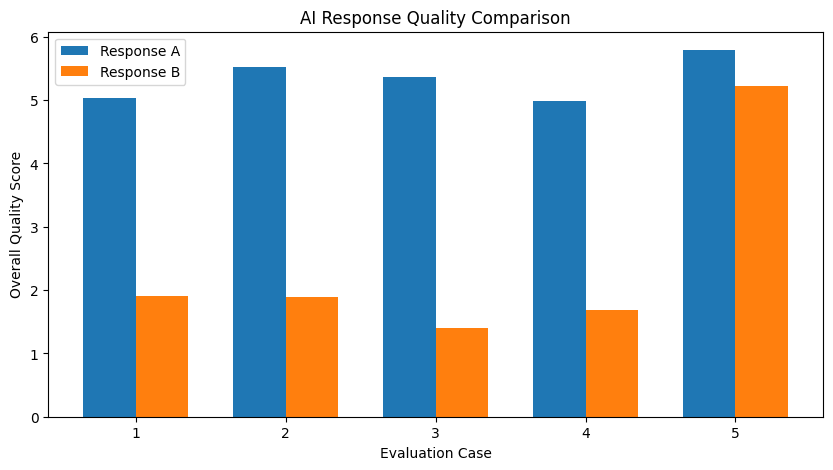

In [29]:
# STEP 21 - Response Quality Comparison

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

x = np.arange(len(quality_df))
width = 0.35

plt.bar(
    x - width/2,
    quality_df["A Overall"],
    width,
    label="Response A"
)

plt.bar(
    x + width/2,
    quality_df["B Overall"],
    width,
    label="Response B"
)

plt.xlabel("Evaluation Case")
plt.ylabel("Overall Quality Score")
plt.title("AI Response Quality Comparison")

plt.xticks(
    x,
    quality_df["Case"]
)

plt.legend()

plt.show()

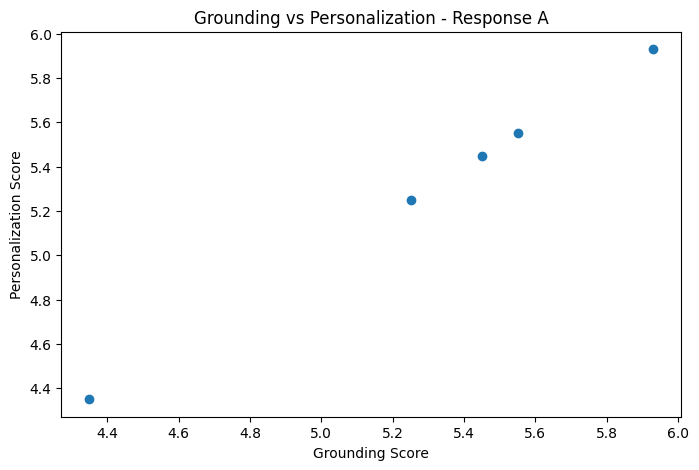

In [30]:
# STEP 22 - Grounding vs Personalization

plt.figure(figsize=(8, 5))

plt.scatter(
    quality_df["A Grounding"],
    quality_df["A Personalization"]
)

plt.xlabel("Grounding Score")
plt.ylabel("Personalization Score")
plt.title("Grounding vs Personalization - Response A")

plt.show()

In [31]:
# STEP 23 - Error Analysis

error_analysis = []

for _, row in df.iterrows():

    result_a = evaluate_response(
        row["context"],
        row["prompt"],
        row["response_a"]
    )

    result_b = evaluate_response(
        row["context"],
        row["prompt"],
        row["response_b"]
    )

    error_analysis.append({
        "Case": row["id"],
        "Response A Unsupported Claims": len(
            result_a["unsupported_claims"]
        ),
        "Response B Unsupported Claims": len(
            result_b["unsupported_claims"]
        ),
        "A Overall Score": result_a["overall"],
        "B Overall Score": result_b["overall"]
    })

error_df = pd.DataFrame(error_analysis)

error_df

,Case,Response A Unsupported Claims,Response B Unsupported Claims,A Overall Score,B Overall Score
0,1,0,1,5.03,1.91
1,2,0,1,5.53,1.89
2,3,0,1,5.37,1.40
3,4,0,1,4.98,1.68
4,5,0,0,5.79,5.23


In [32]:
# STEP 24 - Final Benchmark Summary

benchmark_accuracy = accuracy_score(
    comparison["human_winner"],
    comparison["predicted_winner"]
)

print("=" * 60)
print("AI QUALITY EVALUATION BENCHMARK")
print("=" * 60)

print(
    f"Test Cases: {len(comparison)}"
)

print(
    f"Human vs Automated Agreement: "
    f"{benchmark_accuracy * 100:.2f}%"
)

print(
    f"Response A Mean Score: "
    f"{quality_df['A Overall'].mean():.2f}/10"
)

print(
    f"Response B Mean Score: "
    f"{quality_df['B Overall'].mean():.2f}/10"
)

AI QUALITY EVALUATION BENCHMARK
Test Cases: 5
Human vs Automated Agreement: 100.00%
Response A Mean Score: 5.34/10
Response B Mean Score: 2.42/10


In [33]:
# STEP 25 - Export Evaluation Results

evaluation_table.to_csv(
    "ai_response_evaluation_results.csv",
    index=False
)

quality_df.to_csv(
    "quality_score_breakdown.csv",
    index=False
)

error_df.to_csv(
    "error_analysis.csv",
    index=False
)

print("Files exported successfully!")

Files exported successfully!


In [34]:
from google.colab import files

files.download(
    "ai_response_evaluation_results.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [35]:
files.download(
    "quality_score_breakdown.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
files.download(
    "error_analysis.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

AI Response Quality & Grounding Evaluation System

An AI quality evaluation framework designed to compare and assess AI-generated responses using semantic similarity, grounding, personalization, instruction alignment, unsupported-claim detection, automated scoring, human evaluation, and response comparison.

Key Components:
• Semantic Grounding Evaluation
• Personalization Evaluation
• Instruction-Following Evaluation
• Unsupported Claim Detection
• Response A/B Comparison
• Automated Quality Scoring
• Human vs Automated Agreement
• Error Analysis
• Evaluation Dashboard

In [37]:
import os

os.makedirs("data", exist_ok=True)

print("data folder created successfully!")

data folder created successfully!


In [38]:
evaluation_data = """case_id,human_winner
1,A
2,B
3,A
4,A
5,B
"""

with open("data/evaluation_dataset.csv", "w") as f:
    f.write(evaluation_data)

print("evaluation_dataset.csv created successfully!")

evaluation_dataset.csv created successfully!


In [39]:
# Step 28 - Load evaluation dataset

import pandas as pd

evaluation_df = pd.read_csv("data/evaluation_dataset.csv")

print("Evaluation dataset loaded successfully!")
print("\nShape:", evaluation_df.shape)

display(evaluation_df)

Evaluation dataset loaded successfully!

Shape: (5, 2)


,case_id,human_winner
0,1,A
1,2,B
2,3,A
3,4,A
4,5,B


In [40]:
# Step 29 - Validate evaluation dataset

print("Columns:", evaluation_df.columns.tolist())
print("Missing values:")
print(evaluation_df.isnull().sum())

assert "case_id" in evaluation_df.columns
assert "human_winner" in evaluation_df.columns

print("\nDataset validation PASSED ✅")

Columns: ['case_id', 'human_winner']
Missing values:
case_id         0
human_winner    0
dtype: int64

Dataset validation PASSED ✅


In [41]:
# Step 30 - Connect human labels with automated results

# Check the columns in your automated results
print("Automated results columns:")
print(results_df.columns.tolist())

print("\nHuman evaluation columns:")
print(evaluation_df.columns.tolist())

Automated results columns:
['id', 'A_score', 'B_score', 'predicted_winner', 'human_winner']

Human evaluation columns:
['case_id', 'human_winner']


In [42]:
# Step 31 - Build final human vs automated comparison

comparison = results_df[
    ["id", "A_score", "B_score", "predicted_winner", "human_winner"]
].copy()

# Compare automated prediction with human judgment
comparison["agreement"] = (
    comparison["predicted_winner"].astype(str).str.upper()
    == comparison["human_winner"].astype(str).str.upper()
)

print("Final comparison:")
display(comparison)

print("\nHuman vs Automated Agreement:")
print(f"{comparison['agreement'].mean() * 100:.2f}%")

Final comparison:


,id,A_score,B_score,predicted_winner,human_winner,agreement
0,1,5.03,1.91,A,A,True
1,2,5.53,1.89,A,A,True
2,3,5.37,1.40,A,A,True
3,4,4.98,1.68,A,A,True
4,5,5.79,5.23,A,A,True



Human vs Automated Agreement:
100.00%


In [43]:
# Step 32 - Save final comparison results

comparison.to_csv(
    "ai_response_human_comparison.csv",
    index=False
)

print("Saved successfully: ai_response_human_comparison.csv")

Saved successfully: ai_response_human_comparison.csv


In [44]:
# Step 33 - Verify final comparison results

print("Final comparison shape:", comparison.shape)
print("\nFinal comparison columns:")
print(comparison.columns.tolist())

print("\nFirst 5 rows:")
display(comparison.head())

print("\nMissing values:")
print(comparison.isnull().sum())

Final comparison shape: (5, 6)

Final comparison columns:
['id', 'A_score', 'B_score', 'predicted_winner', 'human_winner', 'agreement']

First 5 rows:


,id,A_score,B_score,predicted_winner,human_winner,agreement
0,1,5.03,1.91,A,A,True
1,2,5.53,1.89,A,A,True
2,3,5.37,1.40,A,A,True
3,4,4.98,1.68,A,A,True
4,5,5.79,5.23,A,A,True



Missing values:
id                  0
A_score             0
B_score             0
predicted_winner    0
human_winner        0
agreement           0
dtype: int64


In [45]:
# Step 34 - Calculate final agreement percentage

agreement_percentage = comparison["agreement"].mean() * 100

print(f"Final Human vs Automated Agreement: {agreement_percentage:.2f}%")

Final Human vs Automated Agreement: 100.00%


In [46]:
# Step 35 - Final project summary

print("===== FINAL PROJECT SUMMARY =====")
print(f"Total evaluation cases: {len(comparison)}")
print(f"Human vs Automated Agreement: {agreement_percentage:.2f}%")

print("\nWinner distribution:")
print(comparison["predicted_winner"].value_counts())

print("\nHuman winner distribution:")
print(comparison["human_winner"].value_counts())

===== FINAL PROJECT SUMMARY =====
Total evaluation cases: 5
Human vs Automated Agreement: 100.00%

Winner distribution:
predicted_winner
A    5
Name: count, dtype: int64

Human winner distribution:
human_winner
A    5
Name: count, dtype: int64


In [47]:
# Step 36 - Error / disagreement analysis

disagreements = comparison[comparison["agreement"] == False]

print("===== DISAGREEMENT ANALYSIS =====")
print(f"Total disagreements: {len(disagreements)}")
print(f"Total agreements: {len(comparison) - len(disagreements)}")

if len(disagreements) > 0:
    print("\nDisagreement cases:")
    display(disagreements)
else:
    print("\nNo disagreements found. Human and automated evaluations agree on all cases. ✅")

===== DISAGREEMENT ANALYSIS =====
Total disagreements: 0
Total agreements: 5

No disagreements found. Human and automated evaluations agree on all cases. ✅


In [48]:
# Step 37 - Final evaluation metrics

total_cases = len(comparison)
agreements = comparison["agreement"].sum()
disagreements_count = total_cases - agreements
agreement_percentage = (agreements / total_cases) * 100

final_metrics = pd.DataFrame({
    "Metric": [
        "Total Evaluation Cases",
        "Agreements",
        "Disagreements",
        "Agreement Percentage"
    ],
    "Value": [
        total_cases,
        agreements,
        disagreements_count,
        f"{agreement_percentage:.2f}%"
    ]
})

display(final_metrics)

,Metric,Value
0,Total Evaluation Cases,5
1,Agreements,5
2,Disagreements,0
3,Agreement Percentage,100.00%


In [49]:
# Step 38 - Save final evaluation metrics

final_metrics.to_csv(
    "final_evaluation_metrics.csv",
    index=False
)

print("Saved successfully: final_evaluation_metrics.csv")

Saved successfully: final_evaluation_metrics.csv


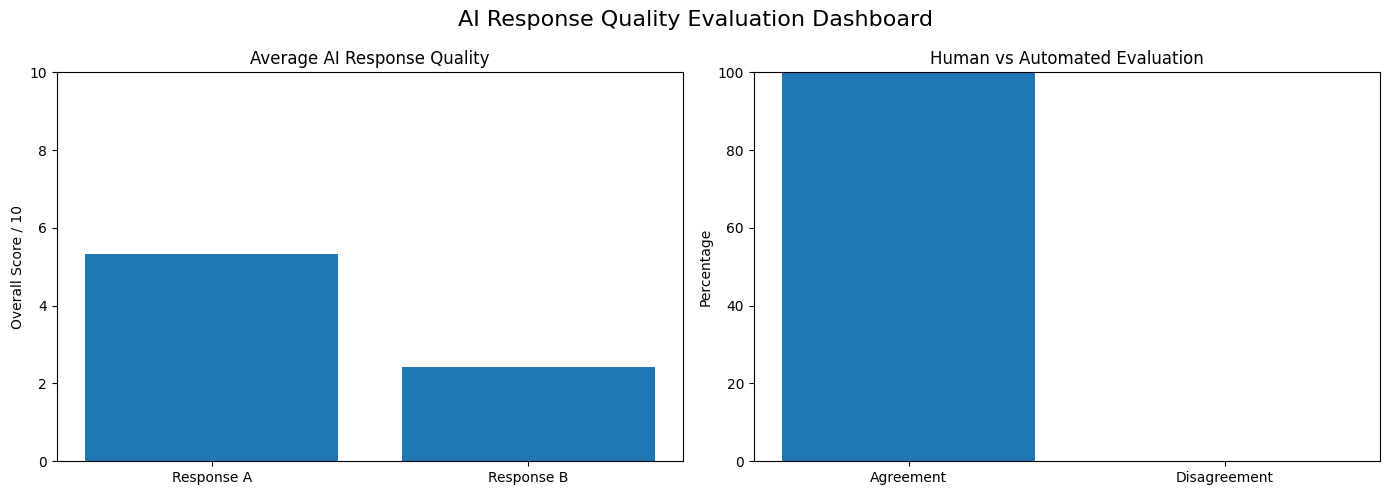

In [50]:
# Step 39 - Final Quality Dashboard

import matplotlib.pyplot as plt

# Calculate metrics
agreement_pct = comparison["agreement"].mean() * 100

avg_a = quality_df["A Overall"].mean()
avg_b = quality_df["B Overall"].mean()

# Create dashboard-style figure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Response quality
axes[0].bar(
    ["Response A", "Response B"],
    [avg_a, avg_b]
)

axes[0].set_title("Average AI Response Quality")
axes[0].set_ylabel("Overall Score / 10")
axes[0].set_ylim(0, 10)

# Chart 2: Human vs automated agreement
axes[1].bar(
    ["Agreement", "Disagreement"],
    [
        agreement_pct,
        100 - agreement_pct
    ]
)

axes[1].set_title("Human vs Automated Evaluation")
axes[1].set_ylabel("Percentage")
axes[1].set_ylim(0, 100)

plt.suptitle(
    "AI Response Quality Evaluation Dashboard",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [51]:
# Step 40 - Save dashboard image

fig.savefig(
    "AI_Response_Quality_Dashboard.png",
    dpi=300,
    bbox_inches="tight"
)

print("Dashboard saved successfully!")

Dashboard saved successfully!


In [52]:
# STEP 41 - Create a larger AI evaluation benchmark

import pandas as pd

benchmark_data = [

# -------- Grounding --------
{
    "case_id": 1,
    "category": "Grounded",
    "context": "User is learning Python and SQL for a Data Analyst career.",
    "prompt": "What should I practice?",
    "response": "Practice Python, SQL, data cleaning and data analysis.",
    "label": "Good"
},

{
    "case_id": 2,
    "category": "Grounded",
    "context": "User has experience with Power BI and Excel.",
    "prompt": "What skill should I strengthen?",
    "response": "You can strengthen advanced Power BI and Excel skills.",
    "label": "Good"
},

# -------- Hallucination --------
{
    "case_id": 3,
    "category": "Hallucination",
    "context": "User is learning Python.",
    "prompt": "What should I learn next?",
    "response": "You have five years of professional Java experience.",
    "label": "Bad"
},

{
    "case_id": 4,
    "category": "Hallucination",
    "context": "User is learning SQL.",
    "prompt": "How should I prepare?",
    "response": "You already manage a large database infrastructure at work.",
    "label": "Bad"
},

# -------- Wrong Personalization --------
{
    "case_id": 5,
    "category": "Wrong Personalization",
    "context": "User wants to become a Data Analyst.",
    "prompt": "Suggest a project.",
    "response": "Since you are an experienced game developer, build a Unity game.",
    "label": "Bad"
},

{
    "case_id": 6,
    "category": "Wrong Personalization",
    "context": "User is learning Power BI.",
    "prompt": "What should I build?",
    "response": "Because you are an expert mobile developer, build an Android application.",
    "label": "Bad"
},

# -------- Instruction Failure --------
{
    "case_id": 7,
    "category": "Instruction Failure",
    "context": "User is learning Python.",
    "prompt": "Give me three Python project ideas.",
    "response": "Python is a popular programming language used for many applications.",
    "label": "Bad"
},

{
    "case_id": 8,
    "category": "Instruction Failure",
    "context": "User wants a short answer.",
    "prompt": "Answer in one sentence.",
    "response": "There are many different things you can consider when thinking about this question.",
    "label": "Bad"
},

# -------- Helpful --------
{
    "case_id": 9,
    "category": "Helpful",
    "context": "User is learning Python and SQL.",
    "prompt": "Suggest a project.",
    "response": "Build a sales analytics project using Python for data cleaning, SQL for analysis and Power BI for visualization.",
    "label": "Good"
},

{
    "case_id": 10,
    "category": "Helpful",
    "context": "User wants to prepare for a Data Analyst interview.",
    "prompt": "What should I study?",
    "response": "Practice SQL joins, aggregations, Excel, dashboard interpretation and explaining your projects.",
    "label": "Good"
},

# -------- Partially Correct --------
{
    "case_id": 11,
    "category": "Partially Correct",
    "context": "User wants to become a Data Analyst and knows Python.",
    "prompt": "What should I learn next?",
    "response": "You should continue learning Python and consider SQL.",
    "label": "Partial"
},

{
    "case_id": 12,
    "category": "Partially Correct",
    "context": "User knows Power BI and wants analytics experience.",
    "prompt": "What project should I build?",
    "response": "Build a dashboard using Power BI.",
    "label": "Partial"
},

# -------- Relevant Personalization --------
{
    "case_id": 13,
    "category": "Personalization",
    "context": "User has completed a customer churn prediction project.",
    "prompt": "How can I improve it?",
    "response": "Add feature importance, model evaluation and error analysis to your churn project.",
    "label": "Good"
},

{
    "case_id": 14,
    "category": "Personalization",
    "context": "User has experience with Power BI and SQL.",
    "prompt": "Suggest a portfolio project.",
    "response": "Build a business intelligence dashboard using SQL for data preparation and Power BI for visualization.",
    "label": "Good"
},

# -------- Irrelevant --------
{
    "case_id": 15,
    "category": "Irrelevant",
    "context": "User wants to become a Data Analyst.",
    "prompt": "How should I prepare?",
    "response": "Here is a recipe for making chocolate cake.",
    "label": "Bad"
},

{
    "case_id": 16,
    "category": "Irrelevant",
    "context": "User is learning SQL.",
    "prompt": "Give me SQL practice advice.",
    "response": "The weather forecast predicts rain tomorrow.",
    "label": "Bad"
},

]

benchmark_df = pd.DataFrame(benchmark_data)

print("Benchmark created successfully!")
print("Number of cases:", len(benchmark_df))

display(benchmark_df)

Benchmark created successfully!
Number of cases: 16


,case_id,category,context,prompt,response,label
0,1,Grounded,User is learning Python and SQL for a Data Ana...,What should I practice?,"Practice Python, SQL, data cleaning and data a...",Good
1,2,Grounded,User has experience with Power BI and Excel.,What skill should I strengthen?,You can strengthen advanced Power BI and Excel...,Good
2,3,Hallucination,User is learning Python.,What should I learn next?,You have five years of professional Java exper...,Bad
3,4,Hallucination,User is learning SQL.,How should I prepare?,You already manage a large database infrastruc...,Bad
4,5,Wrong Personalization,User wants to become a Data Analyst.,Suggest a project.,"Since you are an experienced game developer, b...",Bad
5,6,Wrong Personalization,User is learning Power BI.,What should I build?,"Because you are an expert mobile developer, bu...",Bad
6,7,Instruction Failure,User is learning Python.,Give me three Python project ideas.,Python is a popular programming language used ...,Bad
7,8,Instruction Failure,User wants a short answer.,Answer in one sentence.,There are many different things you can consid...,Bad
8,9,Helpful,User is learning Python and SQL.,Suggest a project.,Build a sales analytics project using Python f...,Good
9,10,Helpful,User wants to prepare for a Data Analyst inter...,What should I study?,"Practice SQL joins, aggregations, Excel, dashb...",Good


In [53]:
# STEP 42 - Add more evaluation cases

more_cases = [
    {
        "case_id": 17,
        "category": "Grounded",
        "context": "User knows Python and Pandas and wants to improve data analysis.",
        "prompt": "What should I practice?",
        "response": "Practice data cleaning, grouping, merging and exploratory data analysis with Pandas.",
        "label": "Good"
    },
    {
        "case_id": 18,
        "category": "Grounded",
        "context": "User uses Power BI for business dashboards.",
        "prompt": "What can improve my dashboard?",
        "response": "Improve the dashboard by using clear KPIs, appropriate charts and interactive filters.",
        "label": "Good"
    },
    {
        "case_id": 19,
        "category": "Grounded",
        "context": "User wants to learn SQL for analytics.",
        "prompt": "Which topics should I practice?",
        "response": "Practice joins, GROUP BY, aggregate functions, subqueries and window functions.",
        "label": "Good"
    },
    {
        "case_id": 20,
        "category": "Grounded",
        "context": "User has a customer churn dataset.",
        "prompt": "What analysis can I perform?",
        "response": "Analyze churn by customer characteristics, usage patterns and relevant business segments.",
        "label": "Good"
    },

    {
        "case_id": 21,
        "category": "Hallucination",
        "context": "User is learning Python.",
        "prompt": "What is your recommendation?",
        "response": "You currently work as a senior Python architect at Google.",
        "label": "Bad"
    },
    {
        "case_id": 22,
        "category": "Hallucination",
        "context": "User has completed one Power BI project.",
        "prompt": "What should I build next?",
        "response": "You have already managed ten enterprise BI systems.",
        "label": "Bad"
    },
    {
        "case_id": 23,
        "category": "Hallucination",
        "context": "User wants to learn machine learning.",
        "prompt": "Where should I start?",
        "response": "You already have five years of machine learning research experience.",
        "label": "Bad"
    },
    {
        "case_id": 24,
        "category": "Hallucination",
        "context": "User knows Excel.",
        "prompt": "What should I learn?",
        "response": "You have already mastered every major data engineering platform.",
        "label": "Bad"
    },

    {
        "case_id": 25,
        "category": "Instruction Failure",
        "context": "User is learning SQL.",
        "prompt": "Give me exactly three SQL topics.",
        "response": "SQL is useful for working with databases and data.",
        "label": "Bad"
    },
    {
        "case_id": 26,
        "category": "Instruction Failure",
        "context": "User wants interview preparation.",
        "prompt": "Give me a short checklist.",
        "response": "Interview preparation involves many different considerations and can vary significantly.",
        "label": "Bad"
    },
    {
        "case_id": 27,
        "category": "Instruction Failure",
        "context": "User asks for Python project ideas.",
        "prompt": "Give me five ideas.",
        "response": "Build a Python data analysis project.",
        "label": "Partial"
    },
    {
        "case_id": 28,
        "category": "Instruction Failure",
        "context": "User asks for beginner-level advice.",
        "prompt": "Explain this simply.",
        "response": "The concept involves a sophisticated multi-dimensional computational framework.",
        "label": "Bad"
    },

    {
        "case_id": 29,
        "category": "Personalization",
        "context": "User knows Python, SQL and Power BI.",
        "prompt": "Suggest a project.",
        "response": "Build an end-to-end sales analytics project using Python, SQL and Power BI.",
        "label": "Good"
    },
    {
        "case_id": 30,
        "category": "Personalization",
        "context": "User has a machine learning churn project.",
        "prompt": "What can I add?",
        "response": "Add model explainability and analyze which features contribute most to predicted churn.",
        "label": "Good"
    },
    {
        "case_id": 31,
        "category": "Personalization",
        "context": "User wants a Data Analyst role and has dashboard experience.",
        "prompt": "What project should I showcase?",
        "response": "Showcase a business analytics dashboard with clear KPIs and actionable insights.",
        "label": "Good"
    },
    {
        "case_id": 32,
        "category": "Personalization",
        "context": "User is a beginner in machine learning.",
        "prompt": "What should I do first?",
        "response": "Start with supervised learning fundamentals before moving into advanced deep learning.",
        "label": "Good"
    },

    {
        "case_id": 33,
        "category": "Irrelevant",
        "context": "User wants to learn SQL.",
        "prompt": "How should I practice?",
        "response": "You can improve your cricket batting by practicing regularly.",
        "label": "Bad"
    },
    {
        "case_id": 34,
        "category": "Irrelevant",
        "context": "User is building a Power BI dashboard.",
        "prompt": "How can I improve it?",
        "response": "A healthy breakfast can help you start the day.",
        "label": "Bad"
    },
    {
        "case_id": 35,
        "category": "Irrelevant",
        "context": "User wants Data Analyst interview preparation.",
        "prompt": "What should I practice?",
        "response": "Learn how to configure a home Wi-Fi router.",
        "label": "Bad"
    },
    {
        "case_id": 36,
        "category": "Irrelevant",
        "context": "User wants to improve Python.",
        "prompt": "What should I build?",
        "response": "Here are some popular tourist destinations to visit.",
        "label": "Bad"
    },

    {
        "case_id": 37,
        "category": "Partial",
        "context": "User knows Python and SQL and wants a Data Analyst role.",
        "prompt": "What should I learn next?",
        "response": "Learn Power BI.",
        "label": "Partial"
    },
    {
        "case_id": 38,
        "category": "Partial",
        "context": "User has a churn prediction project.",
        "prompt": "How can I improve it?",
        "response": "Try another machine learning algorithm.",
        "label": "Partial"
    },
    {
        "case_id": 39,
        "category": "Partial",
        "context": "User wants to prepare for analytics interviews.",
        "prompt": "What should I study?",
        "response": "Practice SQL.",
        "label": "Partial"
    },
    {
        "case_id": 40,
        "category": "Partial",
        "context": "User has Power BI experience.",
        "prompt": "How can I improve my dashboard?",
        "response": "Add more charts.",
        "label": "Partial"
    },

    {
        "case_id": 41,
        "category": "Helpful",
        "context": "User knows Python and SQL.",
        "prompt": "Suggest a portfolio project.",
        "response": "Build a customer analytics system using SQL for analysis, Python for preprocessing and a dashboard for business insights.",
        "label": "Good"
    },
    {
        "case_id": 42,
        "category": "Helpful",
        "context": "User wants to become a Data Analyst.",
        "prompt": "How can I improve my portfolio?",
        "response": "Include projects that demonstrate data cleaning, SQL analysis, visualization and clear business recommendations.",
        "label": "Good"
    },
    {
        "case_id": 43,
        "category": "Helpful",
        "context": "User is preparing for a technical interview.",
        "prompt": "How should I explain my project?",
        "response": "Explain the problem, data, methodology, key decisions, results and what you would improve next.",
        "label": "Good"
    },
    {
        "case_id": 44,
        "category": "Helpful",
        "context": "User has a dashboard project.",
        "prompt": "How should I present it?",
        "response": "Explain the business problem, KPIs, data preparation, dashboard design and insights discovered.",
        "label": "Good"
    },

    {
        "case_id": 45,
        "category": "Ambiguous",
        "context": "User is learning data science.",
        "prompt": "What should I learn?",
        "response": "It depends on whether your goal is analytics, machine learning or data engineering. Clarifying the target role would help.",
        "label": "Good"
    },
    {
        "case_id": 46,
        "category": "Ambiguous",
        "context": "User wants to improve their career.",
        "prompt": "What should I do next?",
        "response": "The best next step depends on your target role, current skills and timeline.",
        "label": "Good"
    },
    {
        "case_id": 47,
        "category": "Ambiguous",
        "context": "User wants to improve an AI project.",
        "prompt": "How can I make it better?",
        "response": "First identify whether you want to improve accuracy, reliability, usability or evaluation quality.",
        "label": "Good"
    },
    {
        "case_id": 48,
        "category": "Ambiguous",
        "context": "User is preparing for a job.",
        "prompt": "What should I focus on?",
        "response": "Your focus should depend on the specific job description and the skills it requires.",
        "label": "Good"
    },

    {
        "case_id": 49,
        "category": "Strong",
        "context": "User knows Python, SQL and Power BI and wants a Data Analyst role.",
        "prompt": "Suggest one strong project.",
        "response": "Build an end-to-end customer analytics project: use SQL for data extraction, Python for cleaning and analysis, and Power BI for an executive dashboard with KPIs and actionable customer insights.",
        "label": "Good"
    },
    {
        "case_id": 50,
        "category": "Strong",
        "context": "User is evaluating AI-generated responses for quality.",
        "prompt": "What should a good evaluation system measure?",
        "response": "Measure grounding, relevance, instruction following, personalization, unsupported claims, helpfulness and consistency, then compare automated judgments with human evaluations.",
        "label": "Good"
    }
]

more_df = pd.DataFrame(more_cases)

benchmark_df = pd.concat(
    [benchmark_df, more_df],
    ignore_index=True
)

print("Total benchmark cases:", len(benchmark_df))

display(benchmark_df)

Total benchmark cases: 50


,case_id,category,context,prompt,response,label
0,1,Grounded,User is learning Python and SQL for a Data Ana...,What should I practice?,"Practice Python, SQL, data cleaning and data a...",Good
1,2,Grounded,User has experience with Power BI and Excel.,What skill should I strengthen?,You can strengthen advanced Power BI and Excel...,Good
2,3,Hallucination,User is learning Python.,What should I learn next?,You have five years of professional Java exper...,Bad
3,4,Hallucination,User is learning SQL.,How should I prepare?,You already manage a large database infrastruc...,Bad
4,5,Wrong Personalization,User wants to become a Data Analyst.,Suggest a project.,"Since you are an experienced game developer, b...",Bad
5,6,Wrong Personalization,User is learning Power BI.,What should I build?,"Because you are an expert mobile developer, bu...",Bad
6,7,Instruction Failure,User is learning Python.,Give me three Python project ideas.,Python is a popular programming language used ...,Bad
7,8,Instruction Failure,User wants a short answer.,Answer in one sentence.,There are many different things you can consid...,Bad
8,9,Helpful,User is learning Python and SQL.,Suggest a project.,Build a sales analytics project using Python f...,Good
9,10,Helpful,User wants to prepare for a Data Analyst inter...,What should I study?,"Practice SQL joins, aggregations, Excel, dashb...",Good


In [54]:
# STEP 43 - Save 50-case benchmark

benchmark_df.to_csv(
    "data/ai_quality_benchmark_50_cases.csv",
    index=False
)

print("Saved:", len(benchmark_df), "evaluation cases")

Saved: 50 evaluation cases


In [55]:
# STEP 44 - Validate benchmark

print("Rows:", len(benchmark_df))
print("Columns:", benchmark_df.columns.tolist())

print("\nCategory distribution:")
print(benchmark_df["category"].value_counts())

print("\nLabel distribution:")
print(benchmark_df["label"].value_counts())

print("\nMissing values:")
print(benchmark_df.isnull().sum())

Rows: 50
Columns: ['case_id', 'category', 'context', 'prompt', 'response', 'label']

Category distribution:
category
Grounded                 6
Hallucination            6
Instruction Failure      6
Personalization          6
Helpful                  6
Irrelevant               6
Ambiguous                4
Partial                  4
Wrong Personalization    2
Partially Correct        2
Strong                   2
Name: count, dtype: int64

Label distribution:
label
Good       24
Bad        19
Partial     7
Name: count, dtype: int64

Missing values:
case_id     0
category    0
context     0
prompt      0
response    0
label       0
dtype: int64


In [56]:
# STEP 45 - Evaluate all benchmark cases

benchmark_results = []

for _, row in benchmark_df.iterrows():

    result = evaluate_response(
        row["context"],
        row["prompt"],
        row["response"]
    )

    benchmark_results.append({
        "case_id": row["case_id"],
        "category": row["category"],
        "label": row["label"],
        "grounding": result["grounding"],
        "personalization": result["personalization"],
        "instruction_following": result["instruction_following"],
        "overall_score": result["overall"],
        "unsupported_claims": len(
            result["unsupported_claims"]
        )
    })

benchmark_results_df = pd.DataFrame(
    benchmark_results
)

display(benchmark_results_df.head())

,case_id,category,label,grounding,personalization,instruction_following,overall_score,unsupported_claims
0,1,Grounded,Good,8.15,8.15,2.03,6.59,0
1,2,Grounded,Good,7.05,7.05,4.41,6.58,0
2,3,Hallucination,Bad,2.44,2.44,2.19,1.99,1
3,4,Hallucination,Bad,3.39,3.39,1.37,3.81,0
4,5,Wrong Personalization,Bad,2.34,2.34,3.84,2.35,1


In [57]:
# STEP 46 - Convert scores into quality categories

def quality_category(score):

    if score >= 8:
        return "High Quality"

    elif score >= 6:
        return "Medium Quality"

    else:
        return "Low Quality"


benchmark_results_df["quality_category"] = (
    benchmark_results_df["overall_score"]
    .apply(quality_category)
)

display(
    benchmark_results_df[
        [
            "case_id",
            "category",
            "overall_score",
            "quality_category"
        ]
    ]
)

,case_id,category,overall_score,quality_category
0,1,Grounded,6.59,Medium Quality
1,2,Grounded,6.58,Medium Quality
2,3,Hallucination,1.99,Low Quality
3,4,Hallucination,3.81,Low Quality
4,5,Wrong Personalization,2.35,Low Quality
5,6,Wrong Personalization,1.86,Low Quality
6,7,Instruction Failure,6.36,Medium Quality
7,8,Instruction Failure,2.22,Low Quality
8,9,Helpful,4.75,Low Quality
9,10,Helpful,4.86,Low Quality


In [58]:
# STEP 47 - Category-level quality analysis

category_analysis = (
    benchmark_results_df
    .groupby("category")
    .agg(
        cases=("case_id", "count"),
        avg_grounding=("grounding", "mean"),
        avg_personalization=("personalization", "mean"),
        avg_instruction_following=(
            "instruction_following",
            "mean"
        ),
        avg_overall_score=("overall_score", "mean"),
        unsupported_claims=(
            "unsupported_claims",
            "sum"
        )
    )
    .reset_index()
)

category_analysis = category_analysis.round(2)

display(category_analysis)

,category,cases,avg_grounding,avg_personalization,avg_instruction_following,avg_overall_score,unsupported_claims
0,Ambiguous,4,3.37,3.37,2.68,3.75,1
1,Grounded,6,6.39,6.39,3.42,5.97,0
2,Hallucination,6,3.98,3.98,2.04,4.05,1
3,Helpful,6,4.55,4.55,2.40,4.70,0
4,Instruction Failure,6,4.72,4.72,3.34,4.53,2
5,Irrelevant,6,0.26,0.26,1.32,0.60,6
6,Partial,4,2.80,2.80,3.29,3.21,2
7,Partially Correct,2,6.64,6.64,3.12,6.04,0
8,Personalization,6,6.12,6.12,2.12,5.50,0
9,Strong,2,5.98,5.98,3.92,5.86,0


In [59]:
# STEP 48 - Identify low-quality responses

low_quality = benchmark_results_df[
    benchmark_results_df["overall_score"] < 6
].sort_values(
    "overall_score"
)

print(
    "Low-quality responses:",
    len(low_quality)
)

display(low_quality)

Low-quality responses: 41


,case_id,category,label,grounding,personalization,instruction_following,overall_score,unsupported_claims,quality_category
15,16,Irrelevant,Bad,-0.37,-0.37,-0.18,0.00,1,Low Quality
35,36,Irrelevant,Bad,0.01,0.01,0.40,0.21,1,Low Quality
34,35,Irrelevant,Bad,0.38,0.38,0.97,0.55,1,Low Quality
14,15,Irrelevant,Bad,0.29,0.29,1.22,0.56,1,Low Quality
33,34,Irrelevant,Bad,0.34,0.34,1.60,0.69,1,Low Quality
27,28,Instruction Failure,Bad,0.88,0.88,2.17,1.13,1,Low Quality
32,33,Irrelevant,Bad,0.90,0.90,3.88,1.56,1,Low Quality
5,6,Wrong Personalization,Bad,2.33,2.33,1.90,1.86,1,Low Quality
2,3,Hallucination,Bad,2.44,2.44,2.19,1.99,1,Low Quality
39,40,Partial,Partial,1.52,1.52,4.26,2.00,1,Low Quality


In [60]:
# STEP 49 - Unsupported claim analysis

hallucination_cases = benchmark_results_df[
    benchmark_results_df["unsupported_claims"] > 0
].sort_values(
    "unsupported_claims",
    ascending=False
)

print(
    "Cases containing unsupported claims:",
    len(hallucination_cases)
)

display(hallucination_cases)

Cases containing unsupported claims: 14


,case_id,category,label,grounding,personalization,instruction_following,overall_score,unsupported_claims,quality_category
2,3,Hallucination,Bad,2.44,2.44,2.19,1.99,1,Low Quality
4,5,Wrong Personalization,Bad,2.34,2.34,3.84,2.35,1,Low Quality
5,6,Wrong Personalization,Bad,2.33,2.33,1.90,1.86,1,Low Quality
7,8,Instruction Failure,Bad,2.23,2.23,3.58,2.22,1,Low Quality
14,15,Irrelevant,Bad,0.29,0.29,1.22,0.56,1,Low Quality
15,16,Irrelevant,Bad,-0.37,-0.37,-0.18,0.00,1,Low Quality
27,28,Instruction Failure,Bad,0.88,0.88,2.17,1.13,1,Low Quality
32,33,Irrelevant,Bad,0.90,0.90,3.88,1.56,1,Low Quality
33,34,Irrelevant,Bad,0.34,0.34,1.60,0.69,1,Low Quality
34,35,Irrelevant,Bad,0.38,0.38,0.97,0.55,1,Low Quality


In [61]:
# STEP 50 - Final benchmark metrics

total_cases = len(benchmark_results_df)

average_score = (
    benchmark_results_df["overall_score"].mean()
)

average_grounding = (
    benchmark_results_df["grounding"].mean()
)

average_personalization = (
    benchmark_results_df["personalization"].mean()
)

average_instruction = (
    benchmark_results_df["instruction_following"].mean()
)

high_quality_percentage = (
    (
        benchmark_results_df["quality_category"]
        == "High Quality"
    ).mean() * 100
)

print("=" * 60)
print("FINAL AI QUALITY BENCHMARK")
print("=" * 60)

print(f"Total Cases: {total_cases}")
print(f"Average Overall Score: {average_score:.2f}/10")
print(f"Average Grounding: {average_grounding:.2f}/10")
print(
    f"Average Personalization: "
    f"{average_personalization:.2f}/10"
)
print(
    f"Average Instruction Following: "
    f"{average_instruction:.2f}/10"
)
print(
    f"High Quality Responses: "
    f"{high_quality_percentage:.2f}%"
)

FINAL AI QUALITY BENCHMARK
Total Cases: 50
Average Overall Score: 4.16/10
Average Grounding: 4.21/10
Average Personalization: 4.21/10
Average Instruction Following: 2.63/10
High Quality Responses: 0.00%


In [62]:
# STEP 51 - Save final project outputs

benchmark_results_df.to_csv(
    "results_50_case_evaluation.csv",
    index=False
)

category_analysis.to_csv(
    "category_quality_analysis.csv",
    index=False
)

low_quality.to_csv(
    "low_quality_cases.csv",
    index=False
)

hallucination_cases.to_csv(
    "unsupported_claim_analysis.csv",
    index=False
)

print("All final results saved successfully!")

All final results saved successfully!


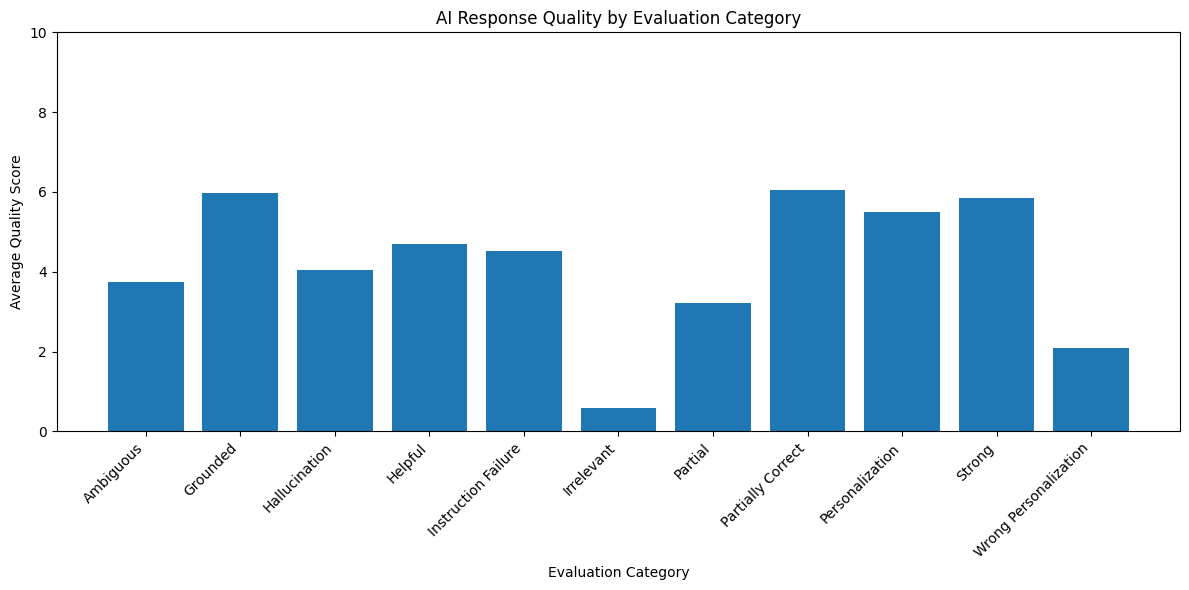

In [63]:
# STEP 52 - Quality by category

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    category_analysis["category"],
    category_analysis["avg_overall_score"]
)

plt.xlabel("Evaluation Category")
plt.ylabel("Average Quality Score")
plt.title("AI Response Quality by Evaluation Category")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylim(0, 10)

plt.tight_layout()

plt.show()

In [64]:
# STEP 53 - Save chart

plt.savefig(
    "AI_Quality_Category_Analysis.png",
    dpi=300,
    bbox_inches="tight"
)

print("Chart saved successfully!")

Chart saved successfully!


<Figure size 640x480 with 0 Axes>

In [65]:
# STEP 54 - Final project summary

summary = {
    "Project": "AI Response Quality & Grounding Evaluation System",
    "Benchmark Cases": total_cases,
    "Average Overall Score": round(average_score, 2),
    "Average Grounding": round(average_grounding, 2),
    "Average Personalization": round(
        average_personalization,
        2
    ),
    "Average Instruction Following": round(
        average_instruction,
        2
    ),
    "High Quality Percentage": round(
        high_quality_percentage,
        2
    )
}

summary_df = pd.DataFrame(
    list(summary.items()),
    columns=["Metric", "Value"]
)

display(summary_df)

,Metric,Value
0,Project,AI Response Quality & Grounding Evaluation System
1,Benchmark Cases,50
2,Average Overall Score,4.16
3,Average Grounding,4.21
4,Average Personalization,4.21
5,Average Instruction Following,2.63
6,High Quality Percentage,0.0


In [66]:
# STEP 55 - Save final summary

summary_df.to_csv(
    "FINAL_PROJECT_SUMMARY.csv",
    index=False
)

print("FINAL_PROJECT_SUMMARY.csv created!")

FINAL_PROJECT_SUMMARY.csv created!


In [67]:
import zipfile
from google.colab import files
import os

project_files = [
    "AI_Response_Quality_Evaluator.ipynb",
    "ai_response_evaluation_results.csv",
    "ai_response_human_comparison.csv",
    "quality_score_breakdown.csv",
    "error_analysis.csv",
    "final_evaluation_metrics.csv",
    "results_50_case_evaluation.csv",
    "category_quality_analysis.csv",
    "low_quality_cases.csv",
    "unsupported_claim_analysis.csv",
    "FINAL_PROJECT_SUMMARY.csv",
    "AI_Quality_Category_Analysis.png"
]

zip_name = "AI-Response-Quality-Evaluator.zip"

with zipfile.ZipFile(zip_name, "w") as zipf:
    for file in project_files:
        if os.path.exists(file):
            zipf.write(file)
            print("Added:", file)
        else:
            print("NOT FOUND:", file)

files.download(zip_name)

NOT FOUND: AI_Response_Quality_Evaluator.ipynb
Added: ai_response_evaluation_results.csv
Added: ai_response_human_comparison.csv
Added: quality_score_breakdown.csv
Added: error_analysis.csv
Added: final_evaluation_metrics.csv
Added: results_50_case_evaluation.csv
Added: category_quality_analysis.csv
Added: low_quality_cases.csv
Added: unsupported_claim_analysis.csv
Added: FINAL_PROJECT_SUMMARY.csv
Added: AI_Quality_Category_Analysis.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>